<a href="https://colab.research.google.com/github/Aravindr017/Image_Classification/blob/main/Model/Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Classification (CNN)

- Using TensorFlow

In [70]:
# Importing Libraries

import tensorflow as tf
import cv2
import numpy as np
import os

In [71]:
# Load Dataset

IMG_SIZE = 128
BATCH_SIZE = 32

train_dir = '/content/drive/MyDrive/ICT - Ai Ml/Deep Learning/Convolutional Neural Network/Images/train'
test_dir = '/content/drive/MyDrive/ICT - Ai Ml/Deep Learning/Convolutional Neural Network/Images/test'

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size = (IMG_SIZE, IMG_SIZE),
    batch_size = BATCH_SIZE
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size = (IMG_SIZE, IMG_SIZE),
    batch_size = BATCH_SIZE
)

class_names = train_dataset.class_names
print('classes : ', class_names)

Found 84 files belonging to 10 classes.
Found 20 files belonging to 10 classes.
classes :  ['Apple', 'Banana', 'Grapes', 'Mango', 'Orange', 'Papaya', 'Pineapple', 'Pomegranate', 'Strawberry', 'Water_Melon']


In [72]:
# Normalize Image ( get the pixels in range of 0 to 1 (basically scale imape pixels to 0 - 1))

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [73]:
# Build CNN Model (Layers using ReLU for feature extraction, and the output dense layer using softmax for classification)

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation = 'relu',
        input_shape = (IMG_SIZE, IMG_SIZE, 3)   # only need to give image size in first layer later take the procesed image from previous layer.
    ),

    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation = 'relu',
    ),

    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(
        128,
        (3,3),
        activation = 'relu',
    ),

    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation = 'relu'
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        len(class_names),
        activation = 'softmax'
    )
])

In [74]:
# Compile The model ( to get initalize the weights and optimization method and loss calculation method) - basically for initalizing the model

model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [75]:
# Training The Model

print(' Training Started : ')

history = model.fit(
    train_dataset,
    validation_data = test_dataset,
    epochs = 40
)

 Training Started : 
Epoch 1/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 919ms/step - accuracy: 0.1071 - loss: 2.4907 - val_accuracy: 0.1000 - val_loss: 2.3321
Epoch 2/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.1548 - loss: 2.3014 - val_accuracy: 0.2000 - val_loss: 2.2257
Epoch 3/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.2024 - loss: 2.1795 - val_accuracy: 0.2500 - val_loss: 2.0691
Epoch 4/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 773ms/step - accuracy: 0.3333 - loss: 1.9654 - val_accuracy: 0.2500 - val_loss: 1.9134
Epoch 5/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 824ms/step - accuracy: 0.4167 - loss: 1.6697 - val_accuracy: 0.3500 - val_loss: 1.7523
Epoch 6/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.3810 - loss: 1.5883 - val_accuracy: 0.3000 - val_loss: 1.6260
Epoch 7/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 808ms/step - accuracy: 0.4881 - loss: 1.3190 - val_accuracy: 0.4500 - val_loss: 1.4268
Epoch 8/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 884ms/step - accuracy: 0.5714 - loss: 1.0767 - val_accuracy: 0.5000

In [76]:
# Saving the model ( because if we dont save we have to retrain the model again for future use it mmay take time and more resources)

model.save('image_class_model.h5')

print('Model saved successfully')

Model saved successfully


In [87]:
# predict test image

test_image_path = '/content/drive/MyDrive/ICT - Ai Ml/Deep Learning/Convolutional Neural Network/Images/test/Grapes/images (3).jpeg' # path of banana image

if not os.path.exists(test_image_path):
  print('Image doesnt exist in the given path, place an image in the path : ', test_image_path)
  exit()


In [88]:
# Read Image using OpenCV
image = cv2.imread(test_image_path)

In [89]:
# Keep original for display
display_image = image.copy()

In [90]:
# Resize for model
image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

In [91]:
# convert BGR to RGB ( for tensorflow models )
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [92]:
# Normalize the test image ( in scale 0-1 )
image = image/255.0

In [93]:
# Add batch dimension
image = np.expand_dims(image, axis=0)

In [94]:
# Predict
prediction = model.predict(image)

predicted_index = np.argmax(prediction)
predicted_fruit = class_names[predicted_index]
confidence = np.max(prediction) * 100


print(f'Prediction : {predicted_fruit}')
print(f'\n Confidence : {confidence:.2f}%')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Prediction : Grapes

 Confidence : 100.00%


array([[[255, 255, 255],
        [254, 254, 254],
        [251, 251, 251],
        ...,
        [249, 249, 249],
        [248, 248, 248],
        [248, 248, 248]],

       [[255, 255, 255],
        [254, 254, 254],
        [251, 251, 251],
        ...,
        [250, 250, 250],
        [246, 246, 246],
        [246, 246, 246]],

       [[255, 255, 255],
        [254, 254, 254],
        [251, 251, 251],
        ...,
        [251, 251, 251],
        [245, 245, 245],
        [245, 245, 245]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [251, 251, 251],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [253, 253, 253],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [253, 253, 253],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
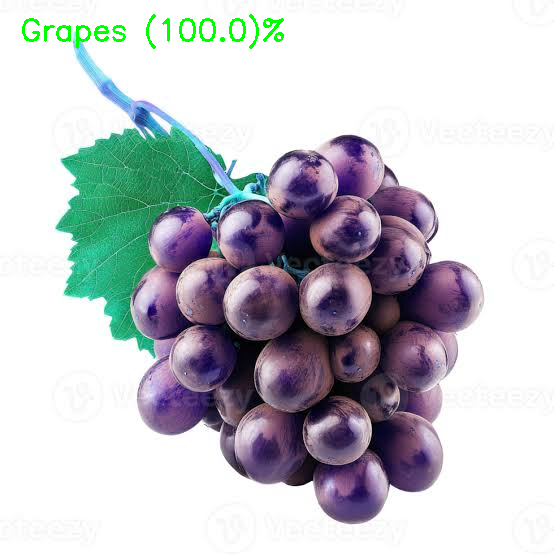

In [95]:
# Display Result with OpenCV
text = f'{predicted_fruit} ({confidence:.1f})%'

cv2.putText(
    display_image,
    text,
    (20,40),
    cv2.FONT_HERSHEY_SIMPLEX,
    1,
    (0, 255, 0),
    2
)

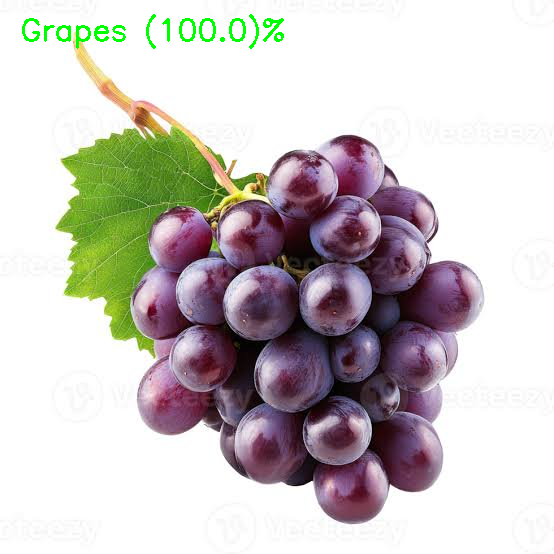

In [96]:
# Displaying image

from google.colab.patches import cv2_imshow # use this for google colab otherwise use cv2.imshow() in cv2 library.
cv2_imshow(display_image)